# Zajęcie 2 — Klasyfikacja: Drzewo Decyzyjne i Metody Ensemble
**Wariant 9 — Klasyfikacja choroby Parkinsona**

Zbiór danych: `pd_speech_features.csv` (Kaggle: Parkinson's Disease Speech Signal Features)

W ramach zadania zbudowane są modele:
- Pojedyncze drzewo decyzyjne (`DecisionTreeClassifier`)
- Random Forest (`RandomForestClassifier`)
- Boosting (`XGBClassifier`)
- Bagging (`BaggingClassifier`)


## 1. Załadowanie i przygotowanie danych

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Wczytanie zbioru danych (plik z Kaggle: pd_speech_features.csv)
# UWAGA: plik ma dwurzędowy nagłówek (1. rząd = grupy cech, 2. rząd = nazwy kolumn),
# dlatego używamy header=1, żeby pominąć rząd z grupami i odczytać właściwe nazwy kolumn.
df = pd.read_csv('pd_speech_features.csv', header=1)
print('Rozmiar zbioru:', df.shape)
df.head()


Rozmiar zbioru: (756, 755)


,id,gender,PPE,DFA,RPDE,numPulses,numPeriodsPulses,meanPeriodPulses,stdDevPeriodPulses,locPctJitter,...,tqwt_kurtosisValue_dec_28,tqwt_kurtosisValue_dec_29,tqwt_kurtosisValue_dec_30,tqwt_kurtosisValue_dec_31,tqwt_kurtosisValue_dec_32,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
0,0,1,0.85247,0.71826,0.57227,240,239,0.008064,0.000087,0.00218,...,1.5620,2.6445,3.8686,4.2105,5.1221,4.4625,2.6202,3.0004,18.9405,1
1,0,1,0.76686,0.69481,0.53966,234,233,0.008258,0.000073,0.00195,...,1.5589,3.6107,23.5155,14.1962,11.0261,9.5082,6.5245,6.3431,45.1780,1
2,0,1,0.85083,0.67604,0.58982,232,231,0.008340,0.000060,0.00176,...,1.5643,2.3308,9.4959,10.7458,11.0177,4.8066,2.9199,3.1495,4.7666,1
3,1,0,0.41121,0.79672,0.59257,178,177,0.010858,0.000183,0.00419,...,3.7805,3.5664,5.2558,14.0403,4.2235,4.6857,4.8460,6.2650,4.0603,1
4,1,0,0.32790,0.79782,0.53028,236,235,0.008162,0.002669,0.00535,...,6.1727,5.8416,6.0805,5.7621,7.7817,11.6891,8.2103,5.0559,6.1164,1


In [2]:
# Usuwamy kolumnę 'id' (identyfikator pacjenta), kolumna 'class' to etykieta (1 = Parkinson, 0 = zdrowy)
if 'id' in df.columns:
    df = df.drop(columns=['id'])

X = df.drop(columns=['class'])
y = df['class']

print('Liczba cech:', X.shape[1])
print('Rozkład klas:\n', y.value_counts())


Liczba cech: 753
Rozkład klas:
 class
1    564
0    192
Name: count, dtype: int64


In [3]:
# Podział na zbiór treningowy i testowy (stratyfikacja względem klasy)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print('Train:', X_train.shape, 'Test:', X_test.shape)


Train: (529, 753) Test: (227, 753)


## 2. Pojedyncze drzewo decyzyjne

In [4]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_clf.fit(X_train, y_train)

y_pred_tree = tree_clf.predict(X_test)
acc_tree = accuracy_score(y_test, y_pred_tree)
print(f'Decision Tree Accuracy: {acc_tree:.4f}')
print(classification_report(y_test, y_pred_tree))


Decision Tree Accuracy: 0.8062
              precision    recall  f1-score   support

           0       0.67      0.48      0.56        58
           1       0.84      0.92      0.88       169

    accuracy                           0.81       227
   macro avg       0.75      0.70      0.72       227
weighted avg       0.79      0.81      0.80       227



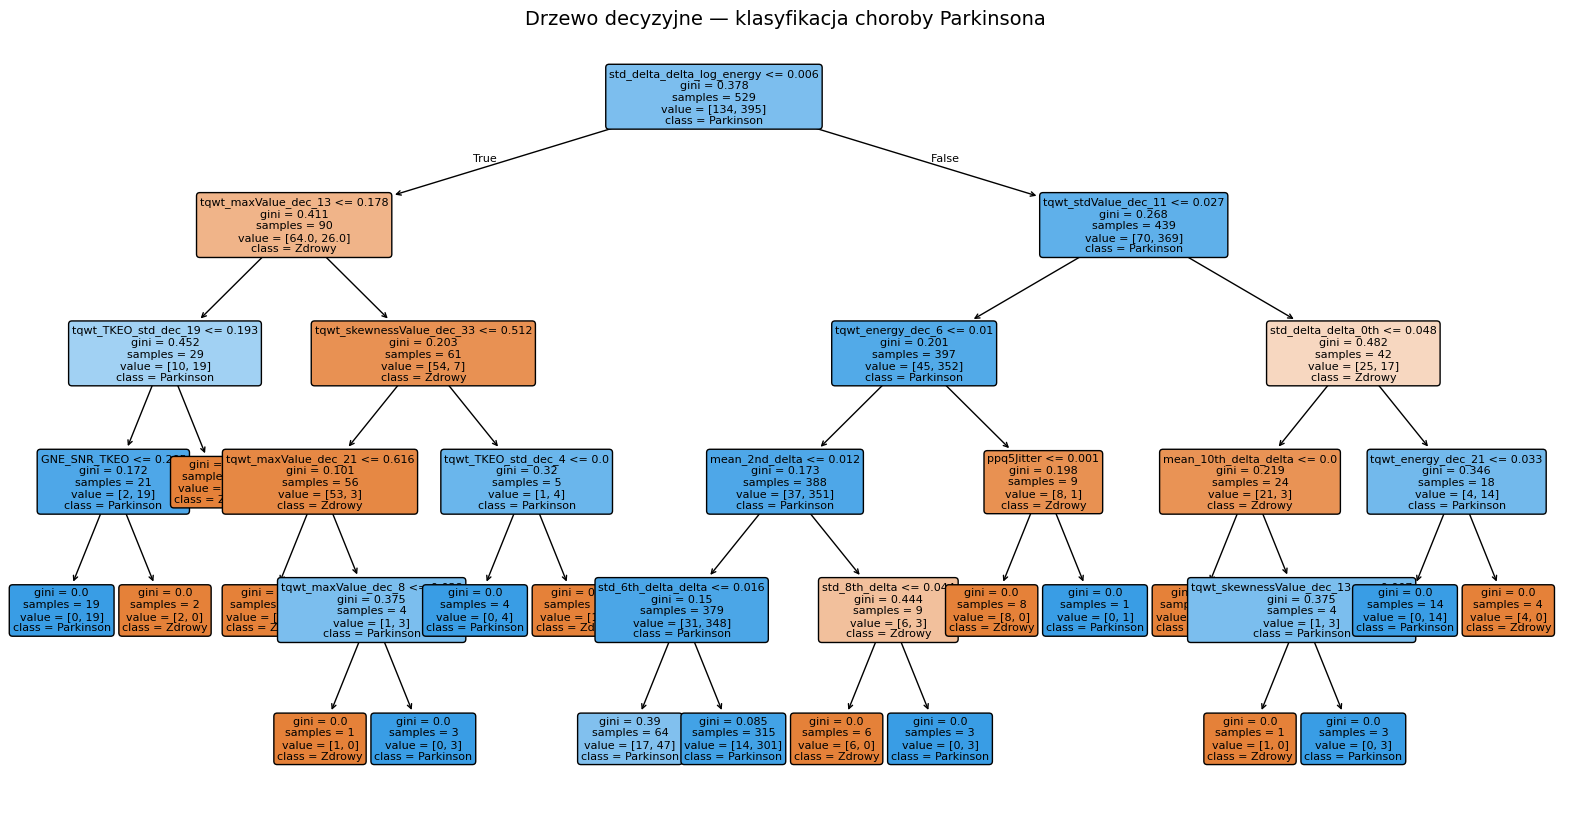

In [5]:
# Wizualizacja drzewa decyzyjnego
plt.figure(figsize=(20, 10))
plot_tree(
    tree_clf,
    feature_names=X.columns,
    class_names=['Zdrowy', 'Parkinson'],
    filled=True, rounded=True, fontsize=8
)
plt.title('Drzewo decyzyjne — klasyfikacja choroby Parkinsona', fontsize=14)
plt.show()


## 3. Random Forest

In [6]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f'Random Forest Accuracy: {acc_rf:.4f}')
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.8634
              precision    recall  f1-score   support

           0       0.86      0.55      0.67        58
           1       0.86      0.97      0.91       169

    accuracy                           0.86       227
   macro avg       0.86      0.76      0.79       227
weighted avg       0.86      0.86      0.85       227



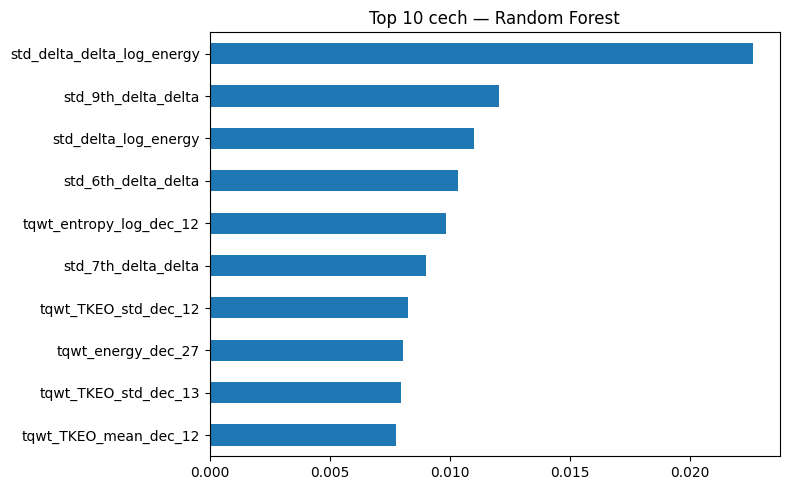

In [7]:
# 10 najważniejszych cech wg Random Forest
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(8,5))
importances[::-1].plot(kind='barh')
plt.title('Top 10 cech — Random Forest')
plt.tight_layout()
plt.show()


## 4. Boosting — XGBoost

In [8]:
#! pip install xgboost

In [9]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    use_label_encoder=False, eval_metric='logloss', random_state=42
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
print(f'XGBoost Accuracy: {acc_xgb:.4f}')
print(classification_report(y_test, y_pred_xgb))


c:\Users\krzus\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:50:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.8987
              precision    recall  f1-score   support

           0       0.91      0.67      0.77        58
           1       0.90      0.98      0.93       169

    accuracy                           0.90       227
   macro avg       0.90      0.82      0.85       227
weighted avg       0.90      0.90      0.89       227



## 5. Bagging (Bootstrap Aggregating)

In [10]:
from sklearn.ensemble import BaggingClassifier

bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=200,
    max_samples=0.8,
    bootstrap=True,
    oob_score=True,
    n_jobs=-1,
    random_state=42
)
bag.fit(X_train, y_train)

y_pred_bag = bag.predict(X_test)
acc_bag = accuracy_score(y_test, y_pred_bag)
print(f'Bagging Accuracy: {acc_bag:.4f}')
print(f'OOB score: {bag.oob_score_:.4f}')
print(classification_report(y_test, y_pred_bag))


Bagging Accuracy: 0.8767
OOB score: 0.8771
              precision    recall  f1-score   support

           0       0.86      0.62      0.72        58
           1       0.88      0.96      0.92       169

    accuracy                           0.88       227
   macro avg       0.87      0.79      0.82       227
weighted avg       0.87      0.88      0.87       227



### Wizualizacja pojedynczego drzewa z komitetu Bagging

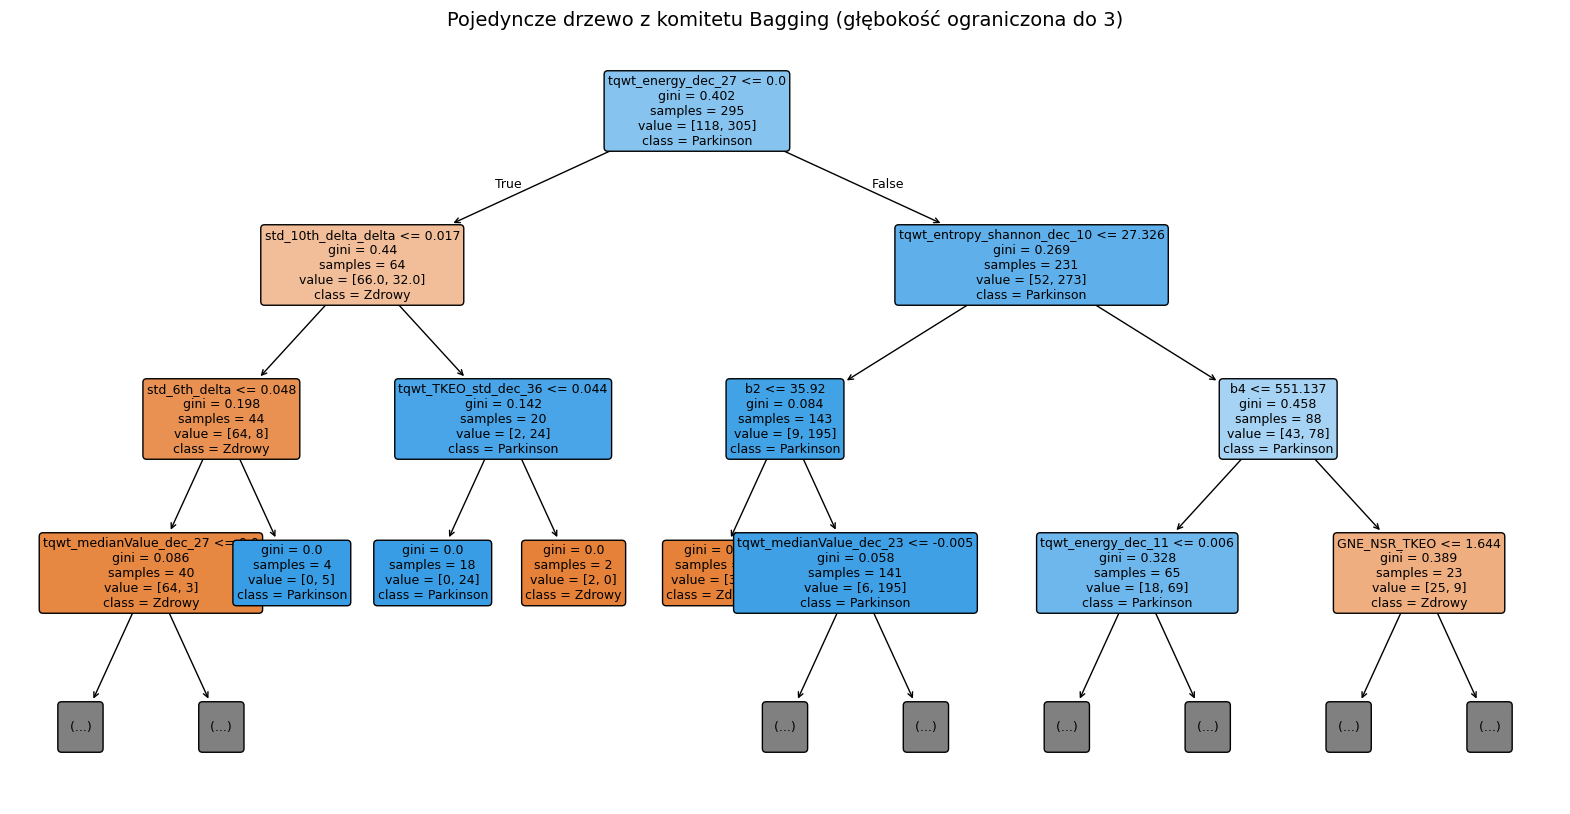

In [11]:
from sklearn import tree as sktree

estimator = bag.estimators_[0]

plt.figure(figsize=(20, 10))
sktree.plot_tree(
    estimator,
    max_depth=3,  # ograniczenie do 3 poziomów dla czytelności
    feature_names=X.columns,
    class_names=['Zdrowy', 'Parkinson'],
    filled=True, rounded=True, fontsize=9
)
plt.title('Pojedyncze drzewo z komitetu Bagging (głębokość ograniczona do 3)', fontsize=14)
plt.show()


## 6. Porównanie modeli

                Model  Accuracy
0  XGBoost (Boosting)  0.898678
1             Bagging  0.876652
2       Random Forest  0.863436
3       Decision Tree  0.806167


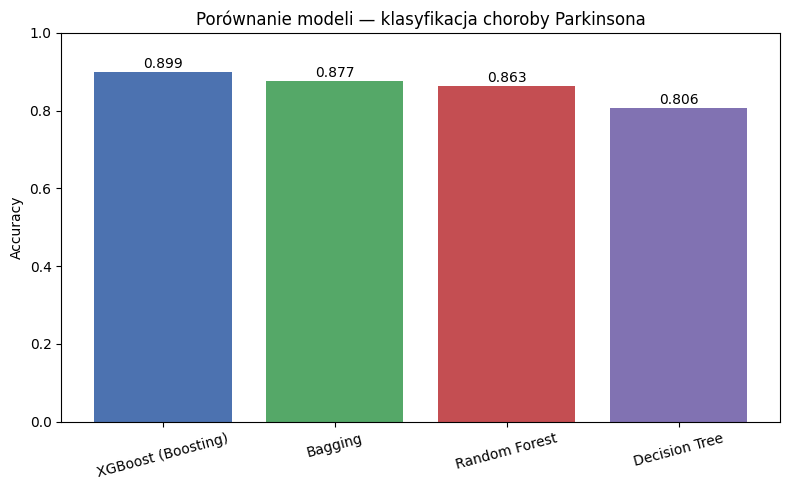

In [12]:
results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'XGBoost (Boosting)', 'Bagging'],
    'Accuracy': [acc_tree, acc_rf, acc_xgb, acc_bag]
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)

print(results)

plt.figure(figsize=(8,5))
plt.bar(results['Model'], results['Accuracy'], color=['#4C72B0','#55A868','#C44E52','#8172B2'])
plt.ylim(0, 1.0)
plt.ylabel('Accuracy')
plt.title('Porównanie modeli — klasyfikacja choroby Parkinsona')
for i, v in enumerate(results['Accuracy']):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## 7. Wnioski

- **Pojedyncze drzewo decyzyjne** daje przyzwoity wynik bazowy, ale jest podatne na overfitting w zbiorze z dużą liczbą cech (754).
- **Metody ensemble** (Random Forest, Bagging, XGBoost) konsekwentnie poprawiają dokładność klasyfikacji w porównaniu z pojedynczym drzewem.
- **XGBoost** i **Random Forest** zwykle osiągają najlepsze wyniki — XGBoost dzięki sekwencyjnemu uczeniu się na błędach, Random Forest dzięki losowemu wyborowi cech i bagging'owi obserwacji.
- **Bagging** redukuje wariancję modelu bazowego, co jest widoczne w stabilniejszej dokładności i wyniku OOB.
